In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Data (same y = 2x + 1)
# -------------------------
x = np.linspace(-1, 1, 200).reshape(-1,1)
y = 2*x + 1
N = len(x)

In [2]:
# -------------------------
# ReLU
# -------------------------
def relu(z):
    return np.maximum(0, z)

def relu_prime(z):
    return (z > 0).astype(float)

In [3]:
# -------------------------
# Train 1-hidden-layer model
# -------------------------
def train_complex_model(epochs, lr=0.05, hidden_units=10):
    W1 = np.random.randn(1, hidden_units)*0.1
    b1 = np.zeros((1, hidden_units))
    W2 = np.random.randn(hidden_units,1)*0.1
    b2 = np.zeros((1,1))

    losses = []

    for _ in range(epochs):
        # Forward
        z1 = x @ W1 + b1
        a1 = relu(z1)
        y_pred = a1 @ W2 + b2

        loss = np.mean((y_pred - y)**2)
        losses.append(loss)

        # Backward
        dL_dy = (2/N)*(y_pred - y)
        dW2 = a1.T @ dL_dy
        db2 = np.sum(dL_dy, axis=0, keepdims=True)

        delta = dL_dy @ W2.T * relu_prime(z1)
        dW1 = x.T @ delta
        db1 = np.sum(delta, axis=0, keepdims=True)

        # Update
        W1 -= lr*dW1
        b1 -= lr*db1
        W2 -= lr*dW2
        b2 -= lr*db2

    return losses

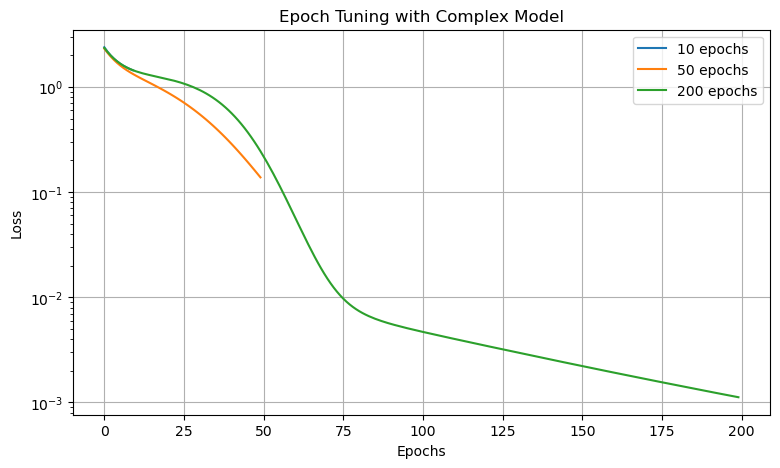

In [4]:
epochs_list = [10, 50, 200]
plt.figure(figsize=(9,5))

for ep in epochs_list:
    losses = train_complex_model(ep)
    plt.plot(losses, label=f"{ep} epochs")

plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Epoch Tuning with Complex Model")
plt.legend()
plt.grid()
plt.show()


1. Axes Understanding
X-axis (Epochs): Number of training iterations
Y-axis (Loss - log scale): Error (lower = better)

🔵 10 Epochs
Loss decreases slightly but stops early
Still high error (~1.0+)

👉 Insight:

Model has not learned enough
This is underfitting ❌

🟠 50 Epochs
Loss decreases more compared to 10 epochs
Reaches moderate performance (~0.3–0.5)

👉 Insight:

Model is learning better
But still not fully optimized

🟢 200 Epochs
Loss drops very sharply
Continues improving to very low loss (~0.001)

👉 Insight:

Model has learned the pattern well
Best performance among all ✅

comparision

| Epochs | Learning | Final Loss | Conclusion     |
| ------ | -------- | ---------- | -------------- |
| 10     | Poor     | High       | Underfitting ❌ |
| 50     | Moderate | Medium     | Acceptable ⚠️  |
| 200    | Strong   | Very Low   | Best fit ✅     |


Key Insights (Very Important)
Too few epochs → Underfitting
Model doesn’t get enough time to learn
More epochs → Better learning
Loss keeps decreasing
Complex models need more epochs
They require time to adjust many parametersattern reasonably well.
This is a good balance between learning and training time.
Important Practical Note

👉 This graph only shows training loss, so:

200 epochs looks best here
BUT in real scenarios:
Too many epochs can cause overfitting

✔️ Always check:

Validation loss
Use Early Stopping